# Product Data Preparation And Exploration Notebook

## *First Purpose*

This notebook transforms the raw Medicine_Details dataset into normalized, EF Core–ready tables:

    Companies

    Categories

    Products

    ProductImages

It generates GUID-based primary keys, maps foreign keys, and enriches missing domain fields.


In [14]:
# imports and Setup
import pandas as pd
import uuid
import random
import matplotlib as mtp
# Load Raw Dataset
df = pd.read_csv("../DataSets/Medicine_Details.csv")



In [15]:
#Company Table Generation
# Extract unique manufacturers and generate Company entities
company_df = (
    df[["Manufacturer"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

company_df["CompanyId"] = [str(uuid.uuid4()) for _ in range(len(company_df))]
company_df["LogoUrl"] = [
    "https://res.cloudinary.com/dwahjkgbk/image/upload/v1761570652/Screenshot_20251027_160704_Chrome_lzsssz.jpg"
    for _ in range(len(company_df))
]
company_df["IsDeleted"] = 0
company_df["ProductsCount"] = 0

company_df.rename(columns={"Manufacturer": "CompanyName"}, inplace=True)

company_df.head()

,CompanyName,CompanyId,LogoUrl,IsDeleted,ProductsCount
0,Roche Products India Pvt Ltd,99973bc4-2556-42da-97fc-844d14c344ed,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
1,Glaxo SmithKline Pharmaceuticals Ltd,0186e0e4-15b3-4bf1-b42a-14c4c61cdcc7,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
2,Alembic Pharmaceuticals Ltd,aa5dc1c9-4f03-49a8-a53d-48ca07c7e169,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
3,Glenmark Pharmaceuticals Ltd,60ed827a-ee15-4ed8-a40b-c7f99a0d8e3d,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
4,Cadila Pharmaceuticals Ltd,bf73abff-3f40-49d8-8087-85412c71292c,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0


In [16]:
# Category Inference & Category Table

def infer_category(row):
    text = f"{row['Medicine Name']} {row['Uses']}".lower()
    if "pain" in text or "fever" in text:
        return "Pain Relief"
    if "cold" in text or "flu" in text:
        return "Cold & Flu"
    if "diabetes" in text:
        return "Diabetes"
    if "antibiotic" in text:
        return "Antibiotics"
    return "General Medicine"

df["CategoryName"] = df.apply(infer_category, axis=1)
category_df = (
    df[["CategoryName"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

category_df["CategoryId"] = [str(uuid.uuid4()) for _ in range(len(category_df))]
category_df["LogoUrl"] = [
    "https://res.cloudinary.com/dwahjkgbk/image/upload/v1761570652/Screenshot_20251027_160704_Chrome_lzsssz.jpg"
    for _ in range(len(category_df))
]
category_df["IsDeleted"] = 0
category_df["ProductsCount"] = 0
category_df.head()

,CategoryName,CategoryId,LogoUrl,IsDeleted,ProductsCount
0,General Medicine,b970bce1-ac82-4f43-aa9f-1fe26d265c26,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
1,Cold & Flu,90129c96-b321-42bc-9f93-918507733e0b,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
2,Pain Relief,fc5d825b-f669-4540-94cf-e17a5f24fc04,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0
3,Diabetes,c630c0d4-4a61-44ab-b608-363cafcd81d4,https://res.cloudinary.com/dwahjkgbk/image/upl...,0,0


In [17]:
# Merge Foreign Keys into Dataset
df = df.merge(
    company_df,
    left_on="Manufacturer",
    right_on="CompanyName",
    how="left"
)

df = df.merge(
    category_df,
    on="CategoryName",
    how="left"
)

In [18]:
# Product Table Creation (C# Model Mapping)
import re



def calculate_rating(row):
    return (
        row["Excellent Review %"] * 5 +
        row["Average Review %"] * 3 +
        row["Poor Review %"] * 1
    ) / 100
def infer_dosage_from_text(row):
    name = str(row['Medicine Name']).lower()
    uses = str(row['Uses']).lower()
    
    if "tablet" in name or "tablet" in uses:
        return "Tablet"
    if "capsule" in name or "capsule" in uses:
        return "Capsule"
    if "syrup" in name or "syrup" in uses or "suspension" in uses:
        return "Syrup"
    if "ointment" in name or "cream" in uses:
        return "Ointment"
    if "drops" in name or "eye" in uses:
        return "Drops"
    if "injection" in name or "iv" in uses:
        return "Injection"
    return "Unknown"

df["DosageForm"] = df.apply(infer_dosage_from_text, axis=1)
df["NameAr"] = None
df["Contraindications"] = df["Side_effects"]

product_df = pd.DataFrame({
    "ProductId": [str(uuid.uuid4()) for _ in range(len(df))],
    "NameEn": df["Medicine Name"],
    "NameAr": df["NameAr"],
    "ActiveIngredients": df["Composition"],
    "Description": df["Uses"],
    "MedicalDescription": df["Uses"],
    "SideEffects": df["Side_effects"],
    "Contraindications": df["Contraindications"],
    "AverageRating": df.apply(calculate_rating, axis=1).round(2),
    "TotalRatings": 100,
    "DiscountPercentage": 0,
    "Price": [random.randint(50, 200) for _ in range(len(df))],
    "IsAvailable": True,
    "IsDeleted": False,
    "DosageForm": df["DosageForm"],
    "CompanyId": df["CompanyId"],
    "CategoryId": df["CategoryId"],
    "Tags": df["Composition"].str.replace(",", " ")
})

product_df.head(1)
def clean_tags(text):
    text = text.lower()
    text = re.sub(r"\d+mg|\d+ml|\d+%", "", text)   # remove dosages
    text = re.sub(r"\([^)]*\)", "", text)         # remove parentheses
    text = re.sub(r"[^a-z, ]", "", text)          # keep letters only
    text = re.sub(r"\s+", " ", text)
    return text.strip()

product_df["Tags"] = product_df["Tags"].apply(clean_tags)
product_df["Tags"] = (
    product_df["Tags"]
    .str.split(",")
    .str[:10]              # cap ingredients
    .str.join(", ")
)


In [19]:
# Product Images Table
Product_Images_df = pd.DataFrame({
    "Id": [str(uuid.uuid4()) for _ in range(len(product_df))],
    "ProductId": product_df["ProductId"],
    "IsPrimary": True,
    "Url": df["Image URL"].values
})

Product_Images_df.head()


,Id,ProductId,IsPrimary,Url
0,a71d1f1b-a05f-46f4-9c6f-6c52b1cf1fc1,236fba7e-45a2-4e63-97ec-bf6e2edc0384,True,"https://onemg.gumlet.io/l_watermark_346,w_480,..."
1,2110dde6-2b02-438e-8ad7-0db3d8ec6ddd,feeb8495-a70c-4fa5-9699-2a686c08c344,True,"https://onemg.gumlet.io/l_watermark_346,w_480,..."
2,f3689ed5-15dd-43b6-a99a-182b1da4df2f,e7a98134-2bb2-42f1-bdd5-e4957b6e1324,True,"https://onemg.gumlet.io/l_watermark_346,w_480,..."
3,ba3eb848-36ba-4f09-b405-9b37351445a9,2b9f0546-7c96-4e36-afd4-aeb98382ee36,True,"https://onemg.gumlet.io/l_watermark_346,w_480,..."
4,bd2b20af-f4bb-41ed-b4ee-f2b1037fd25b,72aca0bc-ae7c-4c5e-b9cd-9c0a451438f3,True,"https://onemg.gumlet.io/l_watermark_346,w_480,..."


In [20]:
# Export CSVs (EF Core Ready)
company_df.to_csv("Companies.csv", index=False)
category_df.to_csv("Categories.csv", index=False)
product_df.to_csv("Products.csv", index=False)
Product_Images_df.to_csv("Product_Images.csv", index=False)



## *Second Purpose EDA*
Exploring Our DataSet , make Sime Visualization and Reports


### Row counts


In [21]:
print("Products:", len(product_df))
print("Companies:", len(company_df))
print("Categories:", len(category_df))
print("Images:", len(Product_Images_df))

Products: 11825
Companies: 759
Categories: 4
Images: 11825


### Primary key uniqueness & Foreign key integrity

In [22]:
assert product_df["ProductId"].is_unique
assert company_df["CompanyId"].is_unique
assert category_df["CategoryId"].is_unique
assert product_df["CompanyId"].isin(company_df["CompanyId"]).all()
assert product_df["CategoryId"].isin(category_df["CategoryId"]).all()


### Missing & Null Analysis

In [23]:
product_df.isnull().mean().sort_values(ascending=False)

NameAr                1.0
ProductId             0.0
DiscountPercentage    0.0
CategoryId            0.0
CompanyId             0.0
DosageForm            0.0
IsDeleted             0.0
IsAvailable           0.0
Price                 0.0
TotalRatings          0.0
NameEn                0.0
AverageRating         0.0
Contraindications     0.0
SideEffects           0.0
MedicalDescription    0.0
Description           0.0
ActiveIngredients     0.0
Tags                  0.0
dtype: float64

In [24]:
product_df[
    ["ActiveIngredients", "Contraindications", "SideEffects", "DosageForm"]
].isnull().sum()


ActiveIngredients    0
Contraindications    0
SideEffects          0
DosageForm           0
dtype: int64

### Distribution Analysis (Business Sense)
*Price distribution*

In [25]:
product_df["Price"].describe()


count    11825.000000
mean       124.829429
std         43.502583
min         50.000000
25%         88.000000
50%        125.000000
75%        162.000000
max        200.000000
Name: Price, dtype: float64

<Axes: title={'center': 'Product Price Distribution'}, ylabel='Frequency'>

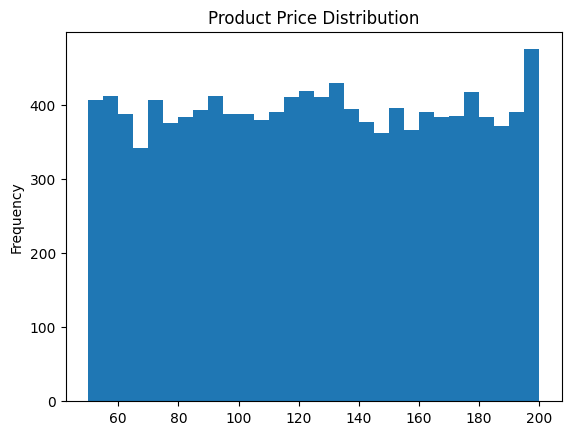

In [26]:
product_df["Price"].plot(kind="hist", bins=30, title="Product Price Distribution")


### Category & Company Balance

*Products per category*

In [27]:
product_df.merge(
    category_df, on="CategoryId"
)["CategoryName"].value_counts()


CategoryName
General Medicine    8580
Pain Relief         1657
Diabetes            1023
Cold & Flu           565
Name: count, dtype: int64

*Products per company*


In [28]:
product_df.merge(
    company_df, on="CompanyId"
)["CompanyName"].value_counts().head(10)


CompanyName
Sun Pharmaceutical Industries Ltd    820
Intas Pharmaceuticals Ltd            654
Cipla Ltd                            574
Torrent Pharmaceuticals Ltd          445
Lupin Ltd                            435
Mankind Pharma Ltd                   337
Zydus Cadila                         327
Alkem Laboratories Ltd               327
Macleods Pharmaceuticals Pvt Ltd     319
Abbott                               279
Name: count, dtype: int64

### Medical Text Quality

*Text length analysis*

➡️ Too short = useless for semantic search 

➡️ Too long = noisy

In [29]:
product_df["MedicalDescription"].str.len().describe()

count    11825.000000
mean        45.288541
std         35.772728
min          5.000000
25%         24.000000
50%         35.000000
75%         53.000000
max        483.000000
Name: MedicalDescription, dtype: float64

In [30]:
product_df["ActiveIngredients"].str.len().describe()


count    11825.000000
mean        33.140550
std         19.838408
min         11.000000
25%         19.000000
50%         24.000000
75%         42.000000
max        274.000000
Name: ActiveIngredients, dtype: float64

*Keyword coverage*

In [31]:
product_df["MedicalDescription"].str.contains(
    "dose|tablet|mg|once|daily", case=False, regex=True
).mean()

8.456659619450317e-05

*Dosage Form Validity*

In [32]:
product_df["DosageForm"].value_counts()

DosageForm
Tablet       6869
Unknown      2167
Capsule      1106
Injection     651
Drops         472
Syrup         358
Ointment      202
Name: count, dtype: int64

### Duplicate Detection


In [33]:
print(product_df["NameEn"].duplicated().sum())
print(product_df["ActiveIngredients"].duplicated().sum())

327
8467


# AI / Semantic Search Readiness

*🔹 Token richness* 

Too few tokens = weak embeddings

In [34]:
product_df["Tags"].str.split().str.len().describe()

count    11825.000000
mean         1.817674
std          1.183120
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         21.000000
Name: Tags, dtype: float64

*🔹 Ingredient overlap* 

Detect dominant compounds (Paracetamol etc.)

In [35]:
from collections import Counter

all_ingredients = " ".join(product_df["ActiveIngredients"]).lower().split(",")
Counter(all_ingredients).most_common(15)


[('bevacizumab (400mg) amoxycillin  (500mg) +  clavulanic acid (125mg) azithromycin (500mg) ambroxol (30mg/5ml) + levosalbutamol (1mg/5ml) + guaifenesin (50mg/5ml) ranitidine (150mg) fexofenadine (120mg) pheniramine (25mg) donepezil (5mg) amoxycillin  (500mg) +  clavulanic acid (125mg) hydroxyzine (25mg) azithromycin (500mg) phenylephrine (0.10% w/w) + beclometasone (0.025% w/w) + lidocaine (2.50% w/w) montelukast (10mg) + fexofenadine (120mg) phenylephrine (5mg) + chlorpheniramine maleate (2mg) + dextromethorphan hydrobromide (10mg) phenylephrine (5mg/5ml) + chlorpheniramine maleate (2mg/5ml) + dextromethorphan hydrobromide (10mg/5ml) anastrozole (1mg) amoxycillin  (200mg) +  clavulanic acid (28.5mg) albendazole (400mg) clonidine (100mcg) fexofenadine (180mg) aceclofenac (200mg) + rabeprazole (20mg) hydroxyzine (10mg) aceclofenac (100mg) + paracetamol (325mg) + serratiopeptidase (10mg) spironolactone (25mg) donepezil (10mg) donepezil (5mg) + memantine (5mg) camphor (0.01% w/v) + menth